<h1 style="text-align: center;" markdown="1">EEIF Quant Research Team</h1>
<h3 style="text-align: center;" markdown="1">Sentiment Analysis</h2>

In [ ]:
# Import packages 
import re
import praw
import nltk
import yfinance as yf
import pandas as pd
from collections import Counter
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timezone

In [ ]:
# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Initialize Reddit API
reddit = praw.Reddit(
    client_id = 'RoqjxD_4oegmPaZn3D56yQ', 
    client_secret = 'bwGK126_Ks1QdKy53tOmO5LMDgMX_Q', 
    user_agent = 'stock-sentiment-time-series'
)

In [ ]:
# Choose subreddit and pull top 1000 posts from today
subreddit = reddit.subreddit("stocks")
posts = subreddit.top(time_filter='day', limit=1000)

In [15]:
# Extract relevant data and analyze sentiment
data = []
for post in posts:
    title = post.title
    selftext = post.selftext
    full_text = title + ' ' + selftext
    
    # VADER sentiment scores
    vader_scores = analyzer.polarity_scores(full_text)
    
    # TextBlob polarity (-1 to 1)
    textblob_polarity = TextBlob(full_text).sentiment.polarity
    
    # Sentiment classification based on compound score
    compound = vader_scores['compound']
    if compound >= 0.05:
        sentiment_label = 'Positive'
    elif compound <= -0.05:
        sentiment_label = 'Negative'
    else:
        sentiment_label = 'Neutral'
    
    data.append({
        'title': title,
        'selftext': selftext,
        'vader_compound': compound,
        'vader_pos': vader_scores['pos'],
        'vader_neu': vader_scores['neu'],
        'vader_neg': vader_scores['neg'],
        'textblob_polarity': textblob_polarity,
        'sentiment_label': sentiment_label,
        'score': post.score,
        'num_comments': post.num_comments,
        'created_utc': datetime.fromtimestamp(post.created_utc, tz=timezone.utc),
        'url': post.url
    })

df = pd.DataFrame(data)

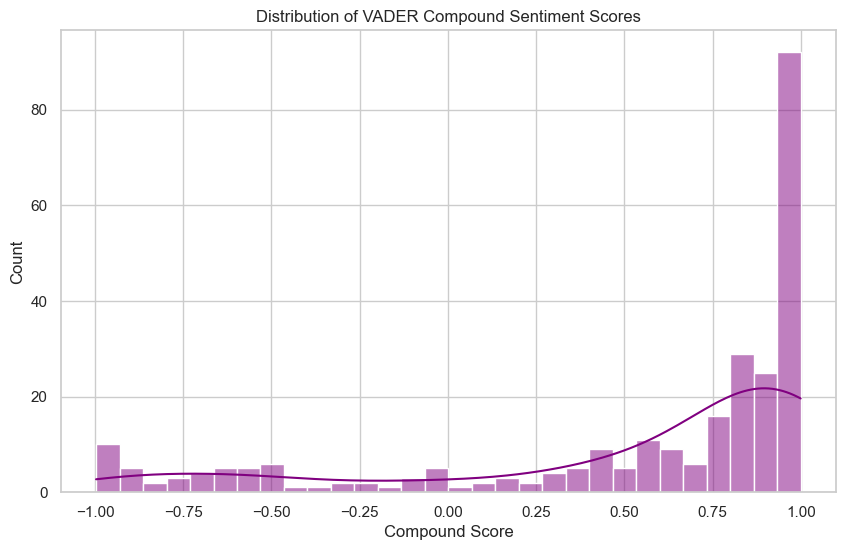

In [16]:
sns.set(style='whitegrid')

# Distribution of VADER compound scores
plt.figure(figsize=(10,6))
sns.histplot(df['vader_compound'], bins=30, kde=True, color='purple')
plt.title('Distribution of VADER Compound Sentiment Scores')
plt.xlabel('Compound Score')
plt.ylabel('Count')
plt.show()

# VADER (Valence Aware Dictionary and sEntiment Reasoner) algorithm
# compound (range from -1 to 1): normalized, weighted composite score that captures the overall sentiment of the text

# KDE (kernel density estimate)

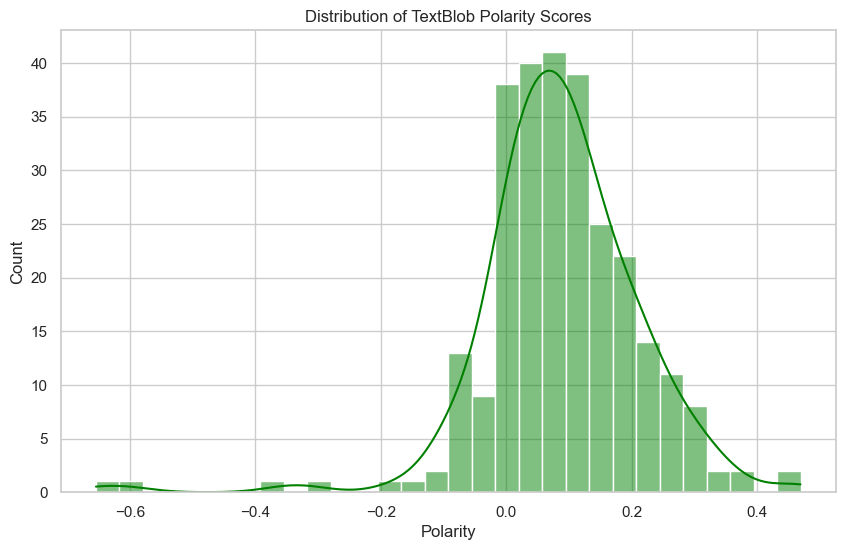

In [17]:
# Distribution of TextBlob polarity
plt.figure(figsize=(10,6))
sns.histplot(df['textblob_polarity'], bins=30, kde=True, color='green')
plt.title('Distribution of TextBlob Polarity Scores')
plt.xlabel('Polarity')
plt.ylabel('Count')
plt.show()

# numerical measure of sentiment that reflects the emotional tone of a given piece of text

/var/folders/07/l8m36_9s2lz170jptjv7r6jc0000gn/T/ipykernel_49736/3110258090.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_label', data=df, palette=['green', 'grey', 'red'])


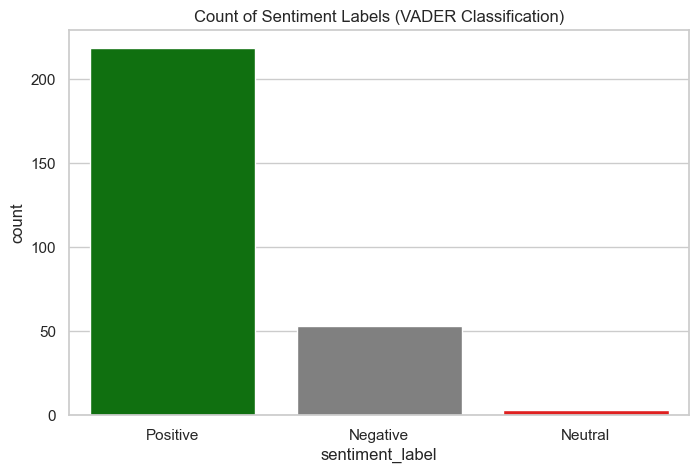

In [18]:
# Sentiment count barplot
plt.figure(figsize=(8,5))
sns.countplot(x='sentiment_label', data=df, palette=['green', 'grey', 'red'])
plt.title('Count of Sentiment Labels (VADER Classification)')
plt.show()

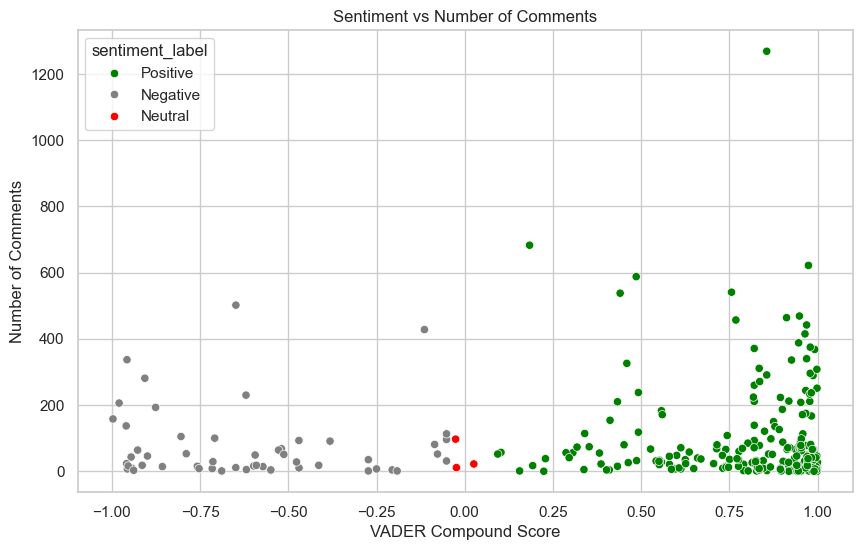

In [19]:
# Scatter plot: Sentiment vs Number of Comments
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='vader_compound', y='num_comments', hue='sentiment_label', palette=['green','grey','red'])
plt.title('Sentiment vs Number of Comments')
plt.xlabel('VADER Compound Score')
plt.ylabel('Number of Comments')
plt.show()

<hr />
<p style="font-family:palatino; text-align: center;font-size: 15px">EEIF Quantitative Research Team</a></p>
<p style="font-family:palatino; text-align: center;font-size: 15px"><em>Jiuyi (Joy) Cheng</em></a></p>
<p style="font-family:palatino; text-align: center;font-size: 15px">Inspired by Emory Department of Economics and QTM</a></p>
